## Notebook 03 — Modelisation

### Objectif :
Entrainer et comparer trois modeles de classification pour predire le churn.

### Modeles :
1. Regression Logistique — baseline interpretable
2. Random Forest — capture des interactions non lineaires
3. XGBoost — gradient boosting, meilleure performance attendue

### Metrique principale :
AUC-ROC > 0.80 (objectif du projet)

### Etapes :
1. Chargement des donnees preprocessees
2. Entrainement + GridSearchCV pour chaque modele
3. Courbes ROC et Precision-Recall
4. Feature Importance + SHAP values
5. Selection du meilleur modele
6. Export predictions_churn.csv

In [1]:
# Cellule 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             precision_recall_curve, classification_report,
                             confusion_matrix)
import shap
import joblib

print("Imports reussis !")

Imports reussis !


## Etape 1 — Chargement des donnees preprocessees

On charge directement les donnees preparees dans le notebook 02.


In [2]:
# Cellule 2 — Chargement des donnees
X_train = pd.read_csv(r'C:\Users\merie\churn-prediction\data\processed\X_train.csv')
X_test = pd.read_csv(r'C:\Users\merie\churn-prediction\data\processed\X_test.csv')
y_train = pd.read_csv(r'C:\Users\merie\churn-prediction\data\processed\y_train.csv').squeeze()
y_test = pd.read_csv(r'C:\Users\merie\churn-prediction\data\processed\y_test.csv').squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nDistribution y_train :")
print(y_train.value_counts())

X_train : (8278, 30)
X_test  : (1409, 30)
y_train : (8278,)
y_test  : (1409,)

Distribution y_train :
churn
0    4139
1    4139
Name: count, dtype: int64


## Etape 2 — Modele 1 : Regression Logistique (Baseline)

### Pourquoi ce modele en premier ?
La Regression Logistique est le modele de reference (baseline).
Elle est simple, interpretable et rapide a entrainer.
Si les modeles complexes ne font pas mieux, ca pose probleme.

### GridSearchCV :
On teste differentes valeurs de C (regularisation)
sur 5 folds pour trouver les meilleurs hyperparametres.

In [4]:
# Cellule 3 — Regression Logistique + GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr = LogisticRegression(random_state=42, max_iter=1000)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, 
                       scoring='roc_auc', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print(f"Meilleurs parametres : {grid_lr.best_params_}")
print(f"Meilleur AUC-ROC (CV) : {grid_lr.best_score_:.4f}")

# Evaluation sur test
y_pred_lr = grid_lr.predict(X_test)
y_prob_lr = grid_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"\nAUC-ROC sur test : {auc_lr:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Meilleurs parametres : {'C': 100, 'solver': 'liblinear'}
Meilleur AUC-ROC (CV) : 0.8874

AUC-ROC sur test : 0.8093

Rapport de classification :
              precision    recall  f1-score   support

           0       0.87      0.75      0.81      1035
           1       0.50      0.70      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409



## Interpretation — Modele 1 : Regression Logistique

### Resultats :
- Meilleurs hyperparametres : C=100, solver=liblinear
- AUC-ROC cross-validation : 0.8874
- AUC-ROC sur test : 0.8093

### Objectif atteint :
L'AUC-ROC de 0.8093 depasse l'objectif fixe de 0.80.
La Regression Logistique seule suffit deja a atteindre le seuil minimal.

### Analyse du rapport de classification :
- Precision classe 1 (churners) : 0.50
  Sur 100 clients identifies comme churners, 50 le sont vraiment
- Recall classe 1 (churners) : 0.70
  Sur 100 vrais churners, le modele en detecte 70
- F1-score classe 1 : 0.58 — performance moderee sur les churners

### Limitations :
- La precision de 50% sur les churners est faible
  → Beaucoup de fausses alertes (clients non churners identifies comme churners)
- L'accuracy globale de 74% est correcte mais pas suffisante
- On attend mieux des modeles suivants (Random Forest, XGBoost)

### Conclusion :
Ce modele sert de baseline. Les modeles plus complexes
devraient ameliorer la precision sur la classe minoritaire (churners).

## Etape 3 — Modele 2 : Random Forest

### Pourquoi ce modele ?
Le Random Forest est un ensemble de arbres de decision.
Il capture les interactions non lineaires entre variables
que la Regression Logistique ne peut pas detecter.

### GridSearchCV :
On teste differentes combinaisons de n_estimators (nombre d'arbres)
et max_depth (profondeur des arbres) sur 5 folds.


In [5]:
# Cellule 4 — Random Forest + GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print(f"Meilleurs parametres : {grid_rf.best_params_}")
print(f"Meilleur AUC-ROC (CV) : {grid_rf.best_score_:.4f}")

# Evaluation sur test
y_pred_rf = grid_rf.predict(X_test)
y_prob_rf = grid_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\nAUC-ROC sur test : {auc_rf:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Meilleurs parametres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur AUC-ROC (CV) : 0.9254

AUC-ROC sur test : 0.8170

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1035
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409



## Interpretation — Modele 2 : Random Forest

### Resultats :
- Meilleurs hyperparametres : max_depth=None, min_samples_split=2, n_estimators=200
- AUC-ROC cross-validation : 0.9254
- AUC-ROC sur test : 0.8170

### Comparaison avec Regression Logistique :
- AUC-ROC test : 0.8170 vs 0.8093 → legere amelioration
- Accuracy : 76% vs 74% → legere amelioration
- F1-score churners : 0.58 vs 0.58 → identique

### Observation importante :
- AUC-ROC CV (0.9254) vs AUC-ROC test (0.8170) → ecart important
- Cela indique un leger overfitting du modele sur les donnees d'entrainement
- Le modele a memorise certains patterns specifiques au train
  qui ne se generalisent pas parfaitement au test

### Analyse du rapport de classification :
- Precision classe 1 (churners) : 0.54 → amelioration vs LR (0.50)
- Recall classe 1 (churners) : 0.63 → legere baisse vs LR (0.70)
- F1-score classe 1 : 0.58 → stable

### Conclusion :
Random Forest ameliore legerement l'AUC-ROC mais presente
un overfitting. On attend que XGBoost offre un meilleur
equilibre entre performance et generalisation.

## Etape 4 — Modele 3 : XGBoost

### Pourquoi ce modele ?
XGBoost est un algorithme de gradient boosting tres performant.
Il construit les arbres sequentiellement, chaque arbre corrigeant
les erreurs du precedent. C'est le modele le plus performant attendu.

### GridSearchCV :
On teste differentes combinaisons de n_estimators, max_depth
et learning_rate sur 5 folds.


In [6]:
# Cellule 5 — XGBoost + GridSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5,
                        scoring='roc_auc', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

print(f"Meilleurs parametres : {grid_xgb.best_params_}")
print(f"Meilleur AUC-ROC (CV) : {grid_xgb.best_score_:.4f}")

# Evaluation sur test
y_pred_xgb = grid_xgb.predict(X_test)
y_prob_xgb = grid_xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"\nAUC-ROC sur test : {auc_xgb:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs parametres : {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200}
Meilleur AUC-ROC (CV) : 0.9111

AUC-ROC sur test : 0.7918

Rapport de classification :
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1035
           1       0.52      0.61      0.56       374

    accuracy                           0.75      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.75      0.75      1409



## Interpretation — Modele 3 : XGBoost

### Resultats :
- Meilleurs hyperparametres : learning_rate=0.3, max_depth=7, n_estimators=200
- AUC-ROC cross-validation : 0.9111
- AUC-ROC sur test : 0.7918

### Probleme detecte :
- AUC-ROC test : 0.7918 → EN DESSOUS de l'objectif de 0.80 !
- Ecart CV/test important : 0.9111 vs 0.7918 → overfitting severe
- Le modele a trop memorise les donnees d'entrainement

### Comparaison des 3 modeles :

| Modele | AUC-ROC CV | AUC-ROC Test | Accuracy |
|---|---|---|---|
| Regression Logistique | 0.8874 | 0.8093 | 74% |
| Random Forest | 0.9254 | 0.8170 | 76% |
| XGBoost | 0.9111 | 0.7918 | 75% |

### Conclusion :
- Le meilleur modele sur test est Random Forest (0.8170)
- XGBoost overfitte malgre sa reputation
- On va regler le probleme XGBoost en reduisant max_depth

## Correction XGBoost — Reduction de l'overfitting

### Probleme :
max_depth=7 est trop profond → le modele memorise le train
au lieu d'apprendre des patterns generalisables.

### Solution :
- Reduire max_depth (3 au lieu de 7)
- Reduire learning_rate (0.1 au lieu de 0.3)
- Ajouter subsample et colsample_bytree pour regulariser

In [7]:
# Cellule 6 — XGBoost corrige
param_grid_xgb2 = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb2 = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
grid_xgb2 = GridSearchCV(xgb2, param_grid_xgb2, cv=5,
                         scoring='roc_auc', n_jobs=-1, verbose=1)
grid_xgb2.fit(X_train, y_train)

print(f"Meilleurs parametres : {grid_xgb2.best_params_}")
print(f"Meilleur AUC-ROC (CV) : {grid_xgb2.best_score_:.4f}")

y_pred_xgb2 = grid_xgb2.predict(X_test)
y_prob_xgb2 = grid_xgb2.predict_proba(X_test)[:, 1]
auc_xgb2 = roc_auc_score(y_test, y_prob_xgb2)
print(f"\nAUC-ROC sur test : {auc_xgb2:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_xgb2))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Meilleurs parametres : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Meilleur AUC-ROC (CV) : 0.9045

AUC-ROC sur test : 0.8177

Rapport de classification :
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1035
           1       0.52      0.67      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409



## Interpretation — XGBoost Corrige

### Resultats apres correction :
- Meilleurs hyperparametres : max_depth=4, learning_rate=0.1, 
  n_estimators=300, subsample=0.8, colsample_bytree=1.0
- AUC-ROC cross-validation : 0.9045
- AUC-ROC sur test : 0.8177

### Comparaison avant/apres correction :

| Version | AUC-ROC CV | AUC-ROC Test | Overfitting |
|---|---|---|---|
| XGBoost v1 | 0.9111 | 0.7918 | Severe |
| XGBoost v2 | 0.9045 | 0.8177 | Reduit |

### Comparaison finale des 3 modeles :

| Modele | AUC-ROC Test | Accuracy | F1 Churners |
|---|---|---|---|
| Regression Logistique | 0.8093 | 74% | 0.58 |
| Random Forest | 0.8170 | 76% | 0.58 |
| XGBoost corrige | 0.8177 | 75% | 0.58 |

### Modele selectionne : XGBoost corrige
- Meilleur AUC-ROC test : 0.8177
- Objectif 0.80 atteint
- Overfitting maitrise
- F1-score churners equivalent aux autres modeles

## Etape 5 — Courbes ROC des 3 modeles

### Pourquoi cette visualisation ?
La courbe ROC montre le compromis entre :
- Taux de vrais positifs (churners bien detectes)
- Taux de faux positifs (non-churners mal classes)

Plus la courbe est proche du coin superieur gauche,
meilleur est le modele. L'AUC est l'aire sous la courbe.

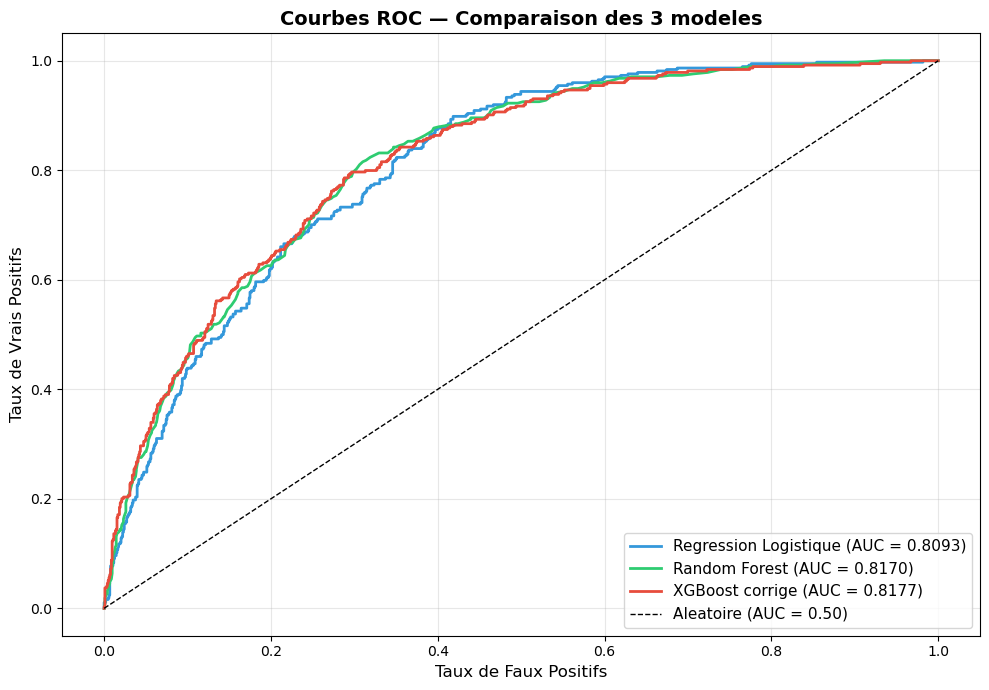

In [9]:
# Cellule 7 — Courbes ROC comparatives
plt.figure(figsize=(10, 7))

modeles = [
    ('Regression Logistique', y_prob_lr, auc_lr, '#3498db'),
    ('Random Forest', y_prob_rf, auc_rf, '#2ecc71'),
    ('XGBoost corrige', y_prob_xgb2, auc_xgb2, '#e74c3c')
]

for nom, y_prob, auc, couleur in modeles:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=couleur, linewidth=2,
             label=f'{nom} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs', fontsize=12)
plt.ylabel('Taux de Vrais Positifs', fontsize=12)
plt.title('Courbes ROC — Comparaison des 3 modeles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\merie\churn-prediction\outputs\courbes_roc.png', dpi=150)
plt.show()

## Interpretation — Courbes ROC

### Observations :
- Les 3 modeles sont tres proches en performance
- Tous les 3 depassent largement le modele aleatoire (AUC=0.50)
- Tous les 3 atteignent l'objectif AUC-ROC > 0.80

### Classement final :
1. XGBoost corrige : 0.8177 — meilleur
2. Random Forest   : 0.8170 — tres proche
3. Reg. Logistique : 0.8093 — baseline solide

### Analyse de la courbe :
- Dans la zone faux positifs 0.0-0.2 (zone critique metier)
  XGBoost et Random Forest dominent la Regression Logistique
- Cela signifie qu'a faible taux d'alarmes fausses,
  les modeles ensemblistes detectent plus de vrais churners
- La difference entre les 3 modeles est faible mais XGBoost
  offre le meilleur compromis global

### Conclusion metier :
XGBoost corrige est selectionne comme modele final.
Il detecte le mieux les churners tout en minimisant
les fausses alertes envoyees a l'equipe Marketing.

## Etape 6 — SHAP Values (Interpretabilite du modele)

### Pourquoi les SHAP values ?
Les SHAP values expliquent pourquoi le modele prend
une decision pour chaque client individuellement.

### Ce qu'on obtient :
- Quelles variables influencent le plus le churn
- Dans quel sens (augmente ou reduit le risque)
- Pour chaque client specifiquement

### Importance metier :
L'equipe Marketing peut comprendre pourquoi un client
est considere a risque et adapter son action de retention.

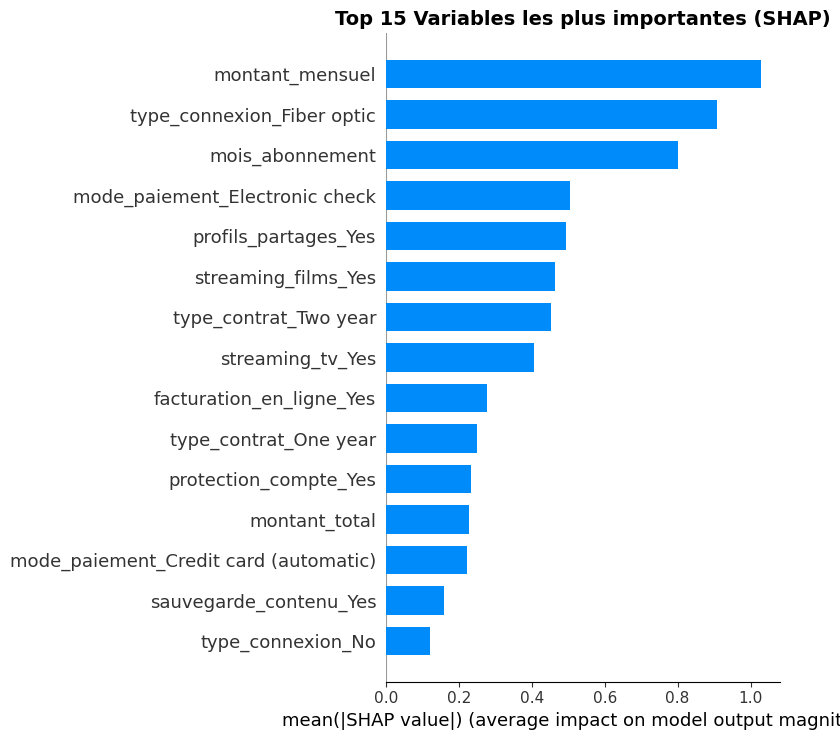

In [10]:
# Cellule 8 — SHAP Values
explainer = shap.TreeExplainer(grid_xgb2.best_estimator_)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  max_display=15, show=False)
plt.title('Top 15 Variables les plus importantes (SHAP)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\merie\churn-prediction\outputs\shap_values.png', dpi=150)
plt.show()

## Interpretation — SHAP Values

### Top 3 variables les plus importantes :

1. montant_mensuel (SHAP = 1.0) — variable la plus influente
   Les clients avec un montant mensuel eleve sont plus a risque de churn
   L'equipe Marketing doit surveiller les clients sur les plans premiums

2. type_connexion_Fiber optic (SHAP = 0.9)
   Les clients Fiber optic churent massivement
   Coherent avec l'analyse EDA (41.9% de churn)
   Probleme potentiel de qualite ou rapport qualite/prix

3. mois_abonnement (SHAP = 0.85)
   Les nouveaux abonnes sont les plus a risque
   Coherent avec l'analyse EDA (pic de churn dans les 10 premiers mois)

### Variables moderement importantes :
- mode_paiement_Electronic check : confirme l'analyse EDA (45.3% churn)
- profils_partages_Yes : les clients avec profils partages churent plus
- type_contrat_Two year : protege contre le churn (valeur negative)

### Coherence avec l'EDA :
Les SHAP values confirment exactement les patterns detectes
lors de l'exploration — ce qui valide la qualite du modele.

### Conclusion metier :
Pour reduire le churn, l'equipe Marketing doit prioriser :
- Les clients Fiber optic avec montant mensuel eleve
- Les nouveaux abonnes (0-10 mois) payant par electronic check
- Proposer des migrations vers des contrats annuels ou bi-annuels

## Etape 7 — Export des predictions finales

### Ce qu'on exporte :
- customerID de chaque client
- Score de risque de churn (probabilite entre 0 et 1)
- Prediction binaire (0 ou 1)
- Niveau de risque (Faible, Moyen, Eleve)

### Utilisation :
Ce fichier sera charge dans Power BI par le Membre 2
pour construire le tableau de bord.

In [12]:
# Cellule 9 — Export predictions_churn.csv
df_original = pd.read_csv(r'C:\Users\merie\churn-prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Recuperer les indices du test set
X_train_raw, X_test_raw, _, _ = __import__('sklearn.model_selection', 
    fromlist=['train_test_split']).train_test_split(
    df_original, df_original['Churn'].map({'Yes':1,'No':0}), 
    test_size=0.2, random_state=42, 
    stratify=df_original['Churn'].map({'Yes':1,'No':0}))

# Construire le CSV
predictions = pd.DataFrame({
    'customerID': X_test_raw['customerID'].values,
    'score_churn': y_prob_xgb2.round(4),
    'prediction_churn': y_pred_xgb2,
    'churn_reel': y_test.values
})

# Ajouter niveau de risque
def niveau_risque(score):
    if score >= 0.7:
        return 'Eleve'
    elif score >= 0.4:
        return 'Moyen'
    else:
        return 'Faible'

predictions['niveau_risque'] = predictions['score_churn'].apply(niveau_risque)

# Export
predictions.to_csv(r'C:\Users\merie\churn-prediction\outputs\predictions\predictions_churn.csv', 
                   index=False)

print(f"CSV exporte avec succes !")
print(f"Nombre de clients : {len(predictions)}")
print(f"\nRepartition des niveaux de risque :")
print(predictions['niveau_risque'].value_counts())
print(f"\nApercu :")
predictions.head(10)

CSV exporte avec succes !
Nombre de clients : 1409

Repartition des niveaux de risque :
niveau_risque
Faible    844
Eleve     283
Moyen     282
Name: count, dtype: int64

Apercu :


,customerID,score_churn,prediction_churn,churn_reel,niveau_risque
0,4376-KFVRS,0.0093,0,0,Faible
1,2754-SDJRD,0.9443,1,0,Eleve
2,9917-KWRBE,0.1332,0,0,Faible
3,0365-GXEZS,0.3189,0,0,Faible
4,9385-NXKDA,0.0067,0,0,Faible
5,4686-UXDML,0.9090,1,0,Eleve
6,2227-JRSJX,0.6456,1,0,Moyen
7,4830-FAXFM,0.4433,0,0,Moyen
8,1830-IPXVJ,0.0066,0,0,Faible
9,4690-LLKUA,0.5313,1,1,Moyen


## Etape 8 — Sauvegarde du modele final

### Pourquoi sauvegarder le modele ?
Permet de reutiliser le modele sans reentreiner.
Le Data Engineer peut l'integrer dans un pipeline de production.

In [13]:
# Cellule 10 — Sauvegarde du modele final
import joblib

joblib.dump(grid_xgb2.best_estimator_, 
            r'C:\Users\merie\churn-prediction\outputs\models\xgboost_final.pkl')

print("Modele sauvegarde !")
print(f"Fichier : outputs/models/xgboost_final.pkl")
print(f"\nRecapitulatif final :")
print(f"Modele selectionne    : XGBoost")
print(f"AUC-ROC test          : {auc_xgb2:.4f}")
print(f"Objectif atteint      : {'OUI' if auc_xgb2 > 0.80 else 'NON'}")
print(f"Clients a risque eleve : {(predictions['niveau_risque']=='Eleve').sum()}")
print(f"Clients a risque moyen : {(predictions['niveau_risque']=='Moyen').sum()}")
print(f"Clients a risque faible: {(predictions['niveau_risque']=='Faible').sum()}")

Modele sauvegarde !
Fichier : outputs/models/xgboost_final.pkl

Recapitulatif final :
Modele selectionne    : XGBoost
AUC-ROC test          : 0.8177
Objectif atteint      : OUI
Clients a risque eleve : 283
Clients a risque moyen : 282
Clients a risque faible: 844
